# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape )
print("usage", usage.shape )

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()
# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()
# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()
# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(# Cantidad de valores nulos)
print(# Proporción de valores nulos)

SyntaxError: unexpected EOF while parsing (1217860218.py, line 3)

In [11]:
users.isnull().sum()
# cantidad de nulos para usage


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

In [12]:
(users.isnull().sum() / len(users)) * 100

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  depende de la descripcion de la columna, si es importante se debe reportar el sesgo de informacion con la persona responsable, caso contraio la columna no aporta valor se puede ignorar directamente haciendo que en el proceso de limpiza se excluya esta columna
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  se puede imputar dependiendo de el analisis hecho por la persona que lo realiza sustituyendo por el segundo cuartil debido a que es el dato menos volati, en caso de no estar seguro se puede informa del error, con el fin de corregirlo de l manera mas optima, sin sesgos.
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 se imputa el valor correspondiente al analisis usualmente dependiendo de la distribucion de los datos se debera sustituir por el promdeio en caso de que la distribucion de los datos sea equitativa  o la mediana en caso contrario a la anterior mencionada
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?   
- Indica qué harías: ¿imputar, eliminar, ignorar?
- "city" contiene un total de 11.725 % de datos nulos se recomienda examinar dependiendo de los siguientes paso, mientras tanto la columna "churn_date" teniendo el 88.350 % de datos nulos es preferible eliminar y reportar el sesgo debido a que no se encuentra descripcion detallada de la misma

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [32]:
print("total de usuarios")
users["user_id"].nunique()


# explorar columnas numéricas de users

total de usuarios


4000

In [27]:
print(" edad del usuario ")
users["age"].describe()

 edad del usuario 


count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id` tiene un total de "4000" datos unicos, es decir exitse un total de "4000" usuarios unicos lo cual es equitativo al valor total de usuarios dentro del análisis 
- - ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ... se encontraron outliers a simple vista que podrian generar problemas mas adelnate en el analisis, ejemplo claro es el valor minimo siendo -999 lo cual refleja un dato incongruente en la infromacion de algunos usuarios al alguien se presenta una desviacion estandar de "123" conmparado al promedio "33"

In [37]:
# explorar columnas numéricas de usage
usage["id"].nunique() 




40000

In [38]:
usage["id"].count() 




40000

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas el valor total de "user_id" del dataset "users" asi como el de "id" del dataset "Usage" son resultados equivalentes.

In [49]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


In [52]:
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [53]:
(users.notnull().sum() / len(users)) * 100

user_id       100.000
first_name    100.000
last_name     100.000
age           100.000
city           88.275
reg_date      100.000
plan          100.000
churn_date     11.650
dtype: float64

- La columna `city` muestra un total del 88.275 % de datos no nulos haciendo mas evidente el sesgo de informacion que existe en esta columna, con 7 ciudades distintas siendo la ciuddad de "bogota" el mas frevunte con un total de 808 registros
- La columna `plan` contiene un valor equitativo al valor de los usuarios totales, mostarndo dos valores unicos, siendo el plan " basico" el mas adquirido adquirido por los usuarios con un total de 2595 usuarios totales dentro del mismo.

In [66]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` muestra dos valores unicos "text" con un total de 22092
- y "call" dando un total de 17908 registros 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  en la columna "city" del dataset de usuarios se encuentra un sesgo importante de los datos, es decir pueden ser valores 
- ¿Qué acción tomarías?  analizar los typos d datos encontrados viendo si se pueden reemplazar

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [13]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])# completa el código

In [14]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [5]:
# Revisar los años presentes en `reg_date` de users


print("Registros totales:", len(users))
print("Valores no nulos:", users['reg_date'].count())
print("Valores nulos:", users['reg_date'].isna().sum())
print("Fechas únicas:", users['reg_date'].nunique())




Registros totales: 4000
Valores no nulos: 4000
Valores nulos: 0
Fechas únicas: 3961


En `reg_date`, los datos ahora se encuentran en un formato mas legible, asi como tambien se puede observar un valor de 3961 datos, si embargo, segun los datos mostrados una fecha se encuentra con un total 40 veces a lo largo del dataset, lo cual indica un mayor numero de actividad en esa fecha

In [6]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, al anlizar la columna 'date' se identificaron un total de 3950 de registros validos, esto indicae que el 1.25% de los datos se encon ausentes.
Posteriormente, se verificó que estos registros ausentes corresponden a valores nulos (NaN) dentro de la columna.




✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
 La columna `reg_date` dentro del dataset "users" no presenta valores faltantes y contiene 4000 registros válidos. Se identificaron 3961 fechas únicas, lo que indica una alta granularidad temporal en los datos. Adicionalmente, se observó que una fecha específica aparece en 40 registros, mientras que la mayoría de las fechas se presentan una sola vez. Este comportamiento podría estar asociado a una concentración de registros en una fecha determinada y merece una revisión adicional para confirmar si corresponde a un evento real o a una característica propia de la generación de los datos.
Al analizar la columna `date`, se identificaron 3950 registros válidos de un total de 4000 observaciones. Esto indica la existencia de 50 valores faltantes, equivalentes al 1.25% del conjunto de datos.

Posteriormente, se verificó la naturaleza de estos registros ausentes, confirmando que corresponden a valores nulos (`NaN`). Aunque la proporción de datos faltantes es relativamente baja, su presencia debe considerarse durante las etapas de limpieza y preparación de los datos, especialmente en análisis que dependan de la variable temporal.



---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [15]:

# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [16]:
# Reemplazar ? por NA en city
users["city"].replace("NA","?")
users["city"].describe()
users["city"].value_counts()

# Verificar cambios


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [17]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.nan

# Verificar cambios
users["reg_date"].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [18]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(
    lambda x: x.isna().mean() * 100
)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [19]:

# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(
    lambda x: x.isna().mean() * 100
)


type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

### Análisis de valores faltantes en `duration` y `length`

Con el objetivo de determinar el tratamiento adecuado para los valores faltantes, se analizó la relación entre las columnas `duration`, `length` y la variable `type`.

Los resultados muestran que la columna `duration` no presenta valores faltantes en los registros de tipo `call`, mientras que aproximadamente el 99.93% de los registros de tipo `text` carecen de información en dicha variable. De forma complementaria, la columna `length` presenta valores faltantes en aproximadamente el 99.93% de los registros de tipo `call`, mientras que los registros de tipo `text` no presentan ausencia de datos.

Este comportamiento evidencia que los valores faltantes dependen directamente del tipo de registro analizado. Las llamadas telefónicas poseen una duración asociada, pero no una longitud de mensaje, mientras que los mensajes de texto poseen una longitud asociada, pero no una duración. Por lo tanto, la ausencia de información observada es consistente con la naturaleza de los datos y no corresponde a errores de captura o calidad de la información.

En consecuencia, los valores faltantes de ambas columnas se clasifican como MAR (Missing At Random) y se conservarán sin imputación, ya que representan una ausencia legítima de información. Reemplazarlos por valores estimados podría introducir sesgos o información artificial en el análisis posterior.




---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [20]:

# Columnas auxiliares


usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas




# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)




,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [21]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [22]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = pd.merge(users,usage_agg,on="user_id",how="left")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [23]:

# Resumen estadístico de las columnas numéricas
user_profile[
    ['age',
     'cant_mensajes',
     'cant_llamadas',
     'cant_minutos_llamada']
].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [24]:
# Distribución porcentual del tipo de plan
print("Distribucion numerica")
print(user_profile["plan"].value_counts()) #distribuciion de la columa "plan"
print("")
print("Distribucion porcentual")
print((user_profile["plan"].value_counts()/len(user_profile))*100) #se muestra la distribucion en porcentaje
print("")
print("Total de usuarios con plan")
print(user_profile["plan"].notnull().sum()) #se comprueba que no existan valores nulos

Distribucion numerica
Basico     2595
Premium    1405
Name: plan, dtype: int64

Distribucion porcentual
Basico     64.875
Premium    35.125
Name: plan, dtype: float64

Total de usuarios con plan
4000


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

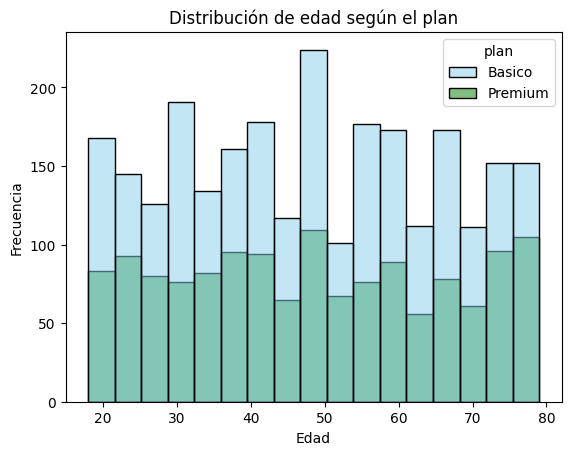

In [45]:
# Histograma para visualizar la edad (age)




sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.title('Distribución de edad según el plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()


💡Insights: 
La distribución de edades muestra una mayor concentración de usuarios entre los 40 y 50 años para ambos planes (Básico y Premium). En contraste, el grupo de usuarios entre 20 y 30 años presenta una menor participación, lo que sugiere una menor tasa de contratación dentro de este rango de edad.

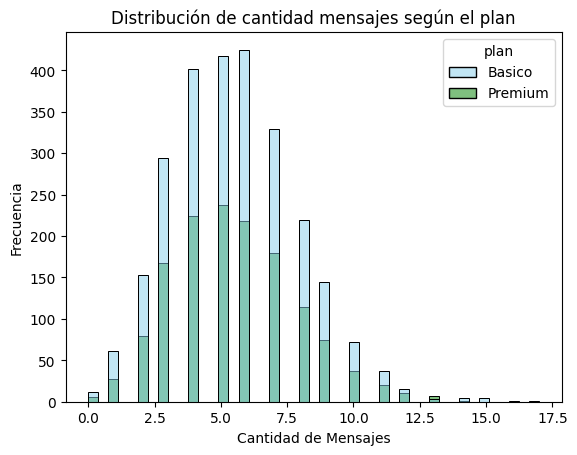

In [46]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.title('Distribución de cantidad mensajes según el plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')

plt.show()


💡Insights: 
La distribución de mensajes enviados muestra un comportamiento similar entre los usuarios de los planes Básico y Premium. En ambos casos, la mayor concentración de observaciones se encuentra entre 2.5 y 7.5 mensajes, lo que indica que la mayoría de los usuarios registra niveles de uso relativamente bajos. Asimismo, se observa una disminución progresiva en la frecuencia conforme aumenta la cantidad de mensajes enviados.

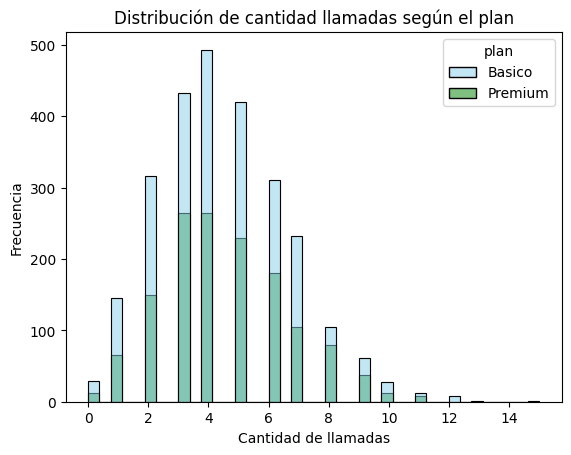

In [48]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.title('Distribución de cantidad llamadas según el plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()


💡Insights: 
La distribución de llamadas presenta un comportamiento similar para los usuarios de los planes Básico y Premium. En ambos casos, la mayor concentración de usuarios se encuentra entre 3 y 6 llamadas, siendo 4 llamadas aproximadamente el valor más frecuente. Asimismo, se observa una disminución progresiva en la frecuencia a medida que aumenta la cantidad de llamadas realizadas, mientras que los usuarios con más de 10 llamadas representan una proporción reducida de la muestra.

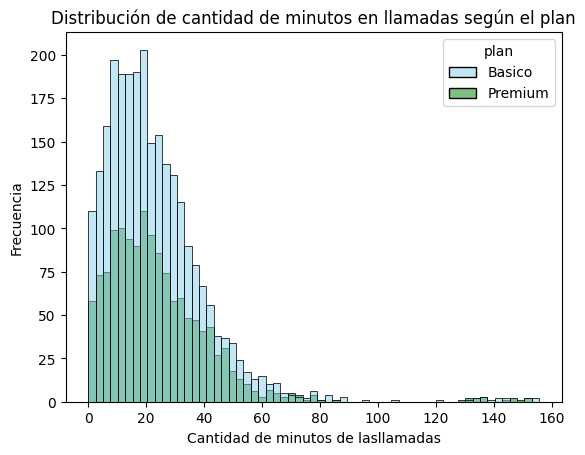

In [51]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)
plt.title('Distribución de cantidad de minutos en llamadas según el plan')
plt.xlabel('Cantidad de minutos de lasllamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
La distribución de los minutos consumidos en llamadas presenta una concentración importante entre los 10 y 30 minutos para ambos planes. Asimismo, se observa una disminución progresiva en la frecuencia de usuarios conforme aumenta la cantidad de minutos utilizados. La distribución muestra una asimetría positiva (sesgo a la derecha), indicando que la mayoría de los usuarios realiza llamadas relativamente cortas, mientras que solo una pequeña proporción acumula consumos elevados de minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

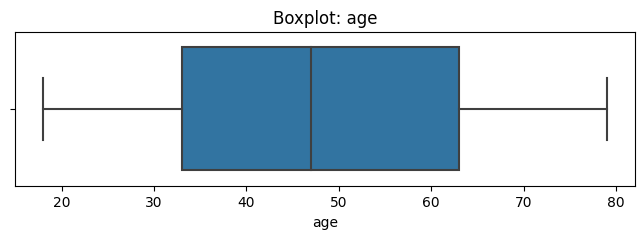

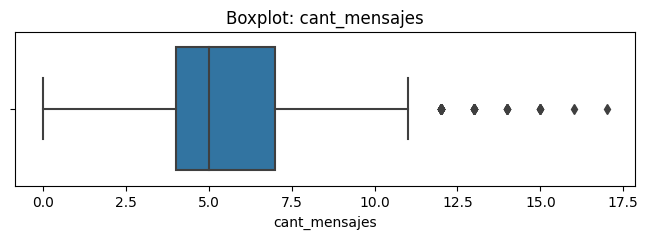

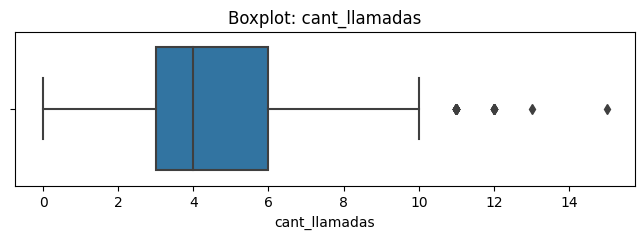

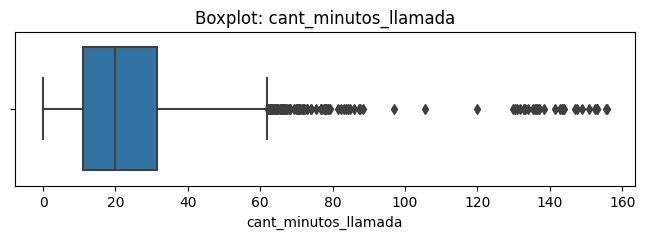

In [26]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=user_profile[col]
    )

    plt.title(f'Boxplot: {col}')

    plt.show()

💡Insights: 
- Age: No se identifican valores atípicos en la variable edad. La mediana se sitúa alrededor de los 47 años y la mitad de los usuarios presenta edades entre 33 y 63 años.
- cant_mensajes: Se identifican algunos valores atípicos en la parte superior de la distribución, correspondientes a usuarios que envían una cantidad de mensajes considerablemente mayor que la mayoría. Sin embargo, estos valores representan un comportamiento plausible dentro del servicio y no sugieren errores evidentes en la captura de datos.
- cant_llamadas: se detectan valores atípicos superiores, estos representan comportamientos plausibles dentro del servicio de telefonía y no parecen corresponder a errores de captura o registro. Por ello, se considera adecuado conservarlos para el análisis posterior.
- cant_minutos_llamada: se identifican numerosos valores atípicos en el extremo superior de la distribución. Sin embargo, estos registros corresponden a usuarios con niveles de consumo elevados y no parecen representar errores de captura de datos. Por lo tanto, se recomienda conservarlos para evitar la pérdida de información relevante sobre patrones de uso poco frecuentes pero reales.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = []



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

- De acuerdo con el análisis exploratorio realizado previamente, se decidió conservar los valores atípicos identificados. Aunque las variables "cant_mensajes", "cant_llamadas" y "cant_minutos_llamada" presentan outliers en el extremo superior de sus distribuciones, estos valores parecen corresponder a comportamientos reales de usuarios con niveles de uso superiores al promedio y no a errores de captura o registro de datos. Por lo tanto, eliminarlos podría generar una pérdida de información relevante e introducir sesgos en el análisis posterior.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [27]:
# Crear columna grupo_uso
def clasificar_uso(row):

    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'

    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(
    clasificar_uso,
    axis=1
)


In [28]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [29]:
# Crear columna grupo_edad
def clasificar_usuario(row):

    if row['age'] < 30 :
        return 'Joven'

    elif row['age'] < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(
    clasificar_usuario,
    axis=1
)


In [30]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

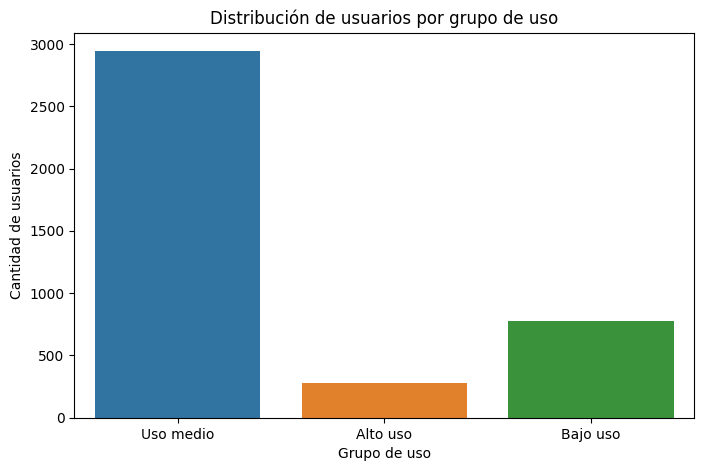

In [32]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,5))

sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()


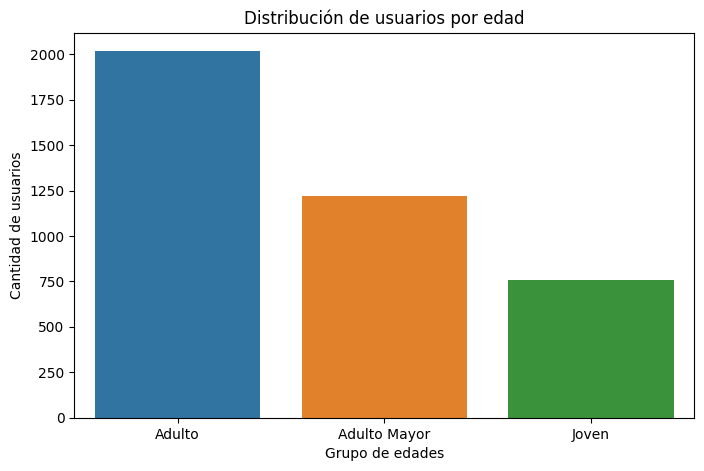

In [33]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,5))

sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de usuarios por edad')
plt.xlabel('Grupo de edades')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? 


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores ausentes en las variables relacionadas con llamadas y mensajes. El análisis mostró que estos valores faltantes están asociados al tipo de actividad registrada (call o text), por lo que corresponden al comportamiento esperado de los datos y no a errores de captura.
- Se identificaron valores ausentes en las variables relacionadas con llamadas y mensajes. El análisis mostró que estos valores faltantes están asociados al tipo de actividad registrada (call o text), por lo que corresponden al comportamiento esperado de los datos y no a errores de captura.
- La variable city presenta registros con valores inconsistentes representados por "?", los cuales podrían requerir una revisión adicional para mejorar la calidad de la información geográfica.


🔍 **Segmentos por Edad**
- La distribución de edades muestra una mayor concentración de usuarios entre los 40 y 60 años, indicando que la base de clientes está compuesta principalmente por adultos.


📊 **Segmentos por Nivel de Uso**
- Se observa una clara concentración de usuarios en el segmento de Uso medio, lo que sugiere que la mayor parte de los clientes mantiene patrones de consumo moderados en términos de llamadas y mensajes. Por otro lado, los usuarios de Alto uso representan una minoría, lo que podría indicar la existencia de un segmento específico con necesidades de comunicación más intensivas.
- 


➡️ Esto sugiere que los servicios móviles son utilizados de manera relativamente homogénea por la mayoría de los clientes, mientras que un grupo reducido concentra niveles de consumo considerablemente más altos. Asimismo, las diferencias entre los planes Básico y Premium no parecen estar asociadas a la edad de los usuarios, sino posiblemente a preferencias de consumo o necesidades particulares de comunicación.

💡 **Recomendaciones**
- Diseñar campañas comerciales dirigidas a los usuarios de alto consumo, ofreciendo beneficios o paquetes adaptados a sus patrones de uso.
- Analizar con mayor profundidad el comportamiento de los usuarios de Alto uso para identificar oportunidades de segmentación y personalización de servicios.
- Implementar controles de calidad sobre variables categóricas como city para reducir registros inconsistentes y mejorar la confiabilidad de futuros análisis.
- Realizar análisis complementarios que incluyan variables de plan, antigüedad del cliente y ubicación geográfica para identificar factores asociados al consumo de servicios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`